# **Task C.1 - Model Development**

## Model Selection
The supervised models that we will be using are 
- Logistic Regression
    - This method is chosen for xyz. This will be the worst option
- Random Forest
    - This method is chosen for its high robustness and strength against overfitting compared it a singular decision tree. Although it is more computationally expensive than logistic regression, 

Even though our datasat might have complex and nonlinear patterns, we believe due to the size and and complexity of the problem that neural networks would be overcomplicated and unnecessary. 

## Data sampling
We considered several well-known splitting methods listed below. The chosen method is _italicized_ and **bolded**:
- Random Splitting: Randomly assign samples to train and test sets. Simple, quick, and easy to implement but not suitable for imbalanced datasets since it disregards any data characteristics.
- Temporal Splitting: Divides data by time. Earlier data samples train model and later samples validate model. Preserves real-world ordering where past events are used to predict future events. However, not suitable for data where there is no time dependency. 
- Stratified Splitting: Divides data into groups (strata) so that class distribution is preserved all training/validation sets. Highly suitable for imbalanced data.
    - Stratified Random Splitting: Split data once, randomly, while preserving class ratios. Simple, fast but results heavily depend on random split.
    - Stratified K-Fold Splitting: Divide data into $K$ folds. Train and validate $K$ times such that every data sample appears in validation exactly once. Computationally expensive.
    - **_Stratified Shuffle Splitting_**: Multiple randomized splits while preserving class ratios. Produce more stable performance estimates than Stratified Random Splitting but at reduced cost of Stratified K-Fold Splitting. Unlike the former, some samples may appear in validation multiple times while others may not appear at all, by virtue of shuffling. Chosen as a good balance between computational complexity and robustness.
    
We are given two different datasets to develop our model. One balanced dataset that will be used for exploratory work and an imbalanced dataset that will be used to train the final model.

First we need to decide how to split our data. Learning from data (site book) states a rule of thumb in practice is to set aside 20 % for validation. This is to manage the conflicitng demands of our validation set. It has to be big enough for our E_val to be reliable, but still small enough so that we will have a big data set for training. 

The imbalanced dataset is highly imbalanced (<<1% fraud), we chose to split and sample the dataset via stratified sampling. Stratified sampling aims to keep:

P(y=1 in split)≈ P(y=1 in original data)

Which is beneficial in our imbalanced case.

We used 10 stratified shuffle splits to make the evaluation less sensitive to one particular random split of the data. This gives a more robust estimate of model performance. We could also have used stratified k-fold cross-validation, where each sample is used once for validation and multiple times for training. However, shuffle splitting gave us more flexibility in controlling the train-validation ratio while preserving the class distribution.

Given the size and complexity of the problem, neural networks would be overcomplicated and unnecessary. 

The training data will be split via stratified sampling. This is due to its high degree of imbalance (<<1% fraud), making stratified sampling the most appropriate. For the data split, we heuristically determined that 80/20, train/test was most suitable. 
N
- explain why use F1 score

C:\Users\ivanc\AppData\Local\Temp\ipykernel_7728\1014799452.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  fraud_rate = creditCard_imbalance.groupby(time_bins)['Class'].mean()


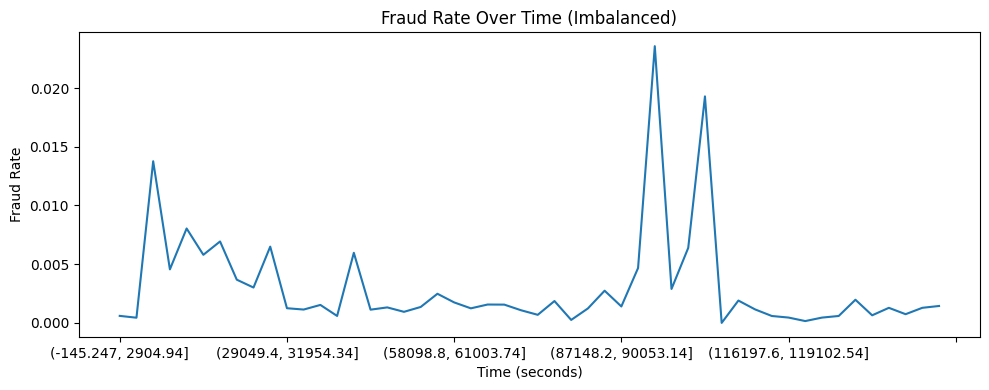

Imbalanced Dataset:
Number of Non-Fraud Transactions: 227428
Number of Fraud Transactions: 417
Balanced Dataset:
Number of Non-Fraud Transactions: 284315
Number of Fraud Transactions: 284315
Imbalanced dataset cells dropped: 0
Balanced dataset cells dropped: 0
(182276, 30) (45569, 30) (182276,) (45569,)


In [1]:
########################
# LOAD AND CLEAN DATA  #
######################## 

import pandas as pd
import matplotlib.pyplot as plt
import csv 
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

# Load datasets
creditCard_imbalance = pd.read_csv('creditcard_imbalanced.csv')
creditCard_balance = pd.read_csv('creditcard_2023.csv')

# Plot and check for time-based patterns in the imbalanced dataset
time_bins = pd.cut(creditCard_imbalance['Time'], bins=50)
fraud_rate = creditCard_imbalance.groupby(time_bins)['Class'].mean()

plt.figure(figsize=(10, 4))
fraud_rate.plot()
plt.title('Fraud Rate Over Time (Imbalanced)')
plt.xlabel('Time (seconds)')
plt.ylabel('Fraud Rate')
plt.tight_layout()
plt.show()
# print number of fraud and non-fraud transactions in the imbalanced dataset
print("Imbalanced Dataset:")
print("Number of Non-Fraud Transactions:", creditCard_imbalance[creditCard_imbalance['Class'] == 0].shape[0])
print("Number of Fraud Transactions:", creditCard_imbalance[creditCard_imbalance['Class'] == 1].shape[0])   

# print number of fraud and non-fraud transactions in the balanced dataset
print("Balanced Dataset:")
print("Number of Non-Fraud Transactions:", creditCard_balance[creditCard_balance['Class'] == 0].shape[0])
print("Number of Fraud Transactions:", creditCard_balance[creditCard_balance['Class'] == 1].shape[0])   

# Clean data
imb_missing_before = creditCard_imbalance.isna().sum().sum()
bal_missing_before = creditCard_balance.isna().sum().sum()

creditCard_imbalance = creditCard_imbalance.dropna()
creditCard_balance = creditCard_balance.dropna()

imb_missing_after = creditCard_imbalance.isna().sum().sum()
bal_missing_after = creditCard_balance.isna().sum().sum()

print(f"Imbalanced dataset cells dropped: {imb_missing_before - imb_missing_after}")
print(f"Balanced dataset cells dropped: {bal_missing_before - bal_missing_after}")

# Split data (numeric columns only for model training)
X_imbalanced = creditCard_imbalance.drop('Class', axis=1).select_dtypes(include=[np.number])
y_imbalanced = creditCard_imbalance['Class']

# Use StratifiedShuffleSplit to split the imbalanced dataset
sss = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
for train_index, test_index in sss.split(X_imbalanced, y_imbalanced):
    X_train_imb, X_valid_imb = X_imbalanced.iloc[train_index], X_imbalanced.iloc[test_index]
    Y_train_imb, Y_valid_imb = y_imbalanced.iloc[train_index], y_imbalanced.iloc[test_index]
print(X_train_imb.shape, X_valid_imb.shape, Y_train_imb.shape, Y_valid_imb.shape)

# Logistic regression Classifier (new)

## Optimizer

Since logistic regression has a convex loss function advanced optimizers such as Adam are not nescessar, instead we can use standard convex optimizer such as LBFGS. LBFGS is a quasi-Newton method which approximates an inverse Hessian matrix to steer its search.

## Weight initialization

Initialize weights independlty from a Normal distribution with zero mean and small variance is often good practice
I don't see what the weights are initialized with in your code

## Regularization


## Termination
A key question that arises when we are using a numerical optimizer is when to stop (is this optimal enough?). 

A common approach is to stop the training when we have hit a maxinum number of iterations (upper bound). However, with this approach there is no guarantee of the quality of the final weights. Therefore we need to combine with another termination criterion (|gradient| < t) (lower bound). 

In [2]:
# Logistic Regression Classifier 
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

# Training with the balanced dataset for exploratory work
# classifier_lr_balanced = LogisticRegression(max_iter=1000, random_state=42)
# classifier_lr_balanced.fit(X_train_b, y_train_b)

tolerance = 0.01 # hyperparameter
max_iterations = 1000 # hyperparameter

# Training our actual model with the "true" imbalanced dataset
classifier_lr_imbalanced = LogisticRegression(max_iter = max_iterations, random_state=42, tol = tolerance)
classifier_lr_imbalanced.fit(X_train_imb, Y_train_imb)

# hva er våre hyperparametre? Hvordan var det man testet dette?
# 

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.01
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multicl

### Random Forest Rationale
The Random Forest classifier is an ensemble supervised learning method. This classifier uses multiple decision trees during training and combines their outputs into a singular result. Overfitting and bias is corrected by virtue of having multiple decision trees (ie the ensemble method). However, Random Forest classifiers are more computationally expensive, complex and time-consuming to individual trees. Nevertheless, their performance justifies said considerations. 

In [3]:
########################
# RANDOM FOREST        #
########################
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV, StratifiedShuffleSplit,RandomizedSearchCV
from sklearn.metrics import classification_report, f1_score

# Step 1 — Train/validation split
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, val_index in sss.split(X_imbalanced, y_imbalanced):
    X_train_imb = X_imbalanced.iloc[train_index]
    X_val_imb   = X_imbalanced.iloc[val_index]
    y_train_imb = y_imbalanced.iloc[train_index]
    y_val_imb   = y_imbalanced.iloc[val_index]

# Keep only numeric columns to avoid dtype errors in sklearn
X_train_imb = X_train_imb.select_dtypes(include=['number'])
X_val_imb = X_val_imb[X_train_imb.columns]

# Sanity check
print(f"Original fraud rate:   {y_imbalanced.mean():.4f}")
print(f"Train fraud rate:      {y_train_imb.mean():.4f}")
print(f"Validation fraud rate: {y_val_imb.mean():.4f}")

# Step 2 — Hyperparameter tuning via Stratified K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Phase 1 — wide random search
param_dist = {
    'n_estimators':      [100, 120],
    'max_depth':         [5, 10],
    'min_samples_split': [2, 5],
    'class_weight':      ['balanced', None]
}

import time

start = time.time()
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=6,          # only tries 6 random combinations
    cv=cv,
    scoring='f1',
    n_jobs=1,
    random_state=42,
    verbose=1
)
random_search.fit(X_train_imb, y_train_imb)
end = time.time()

print(f"Elapsed time: {(end - start)/60:.2f} minutes")
print(f"Best params so far: {random_search.best_params_}")


Original fraud rate:   0.0018
Train fraud rate:      0.0018
Validation fraud rate: 0.0018
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Elapsed time: 12.29 minutes
Best params so far: {'n_estimators': 120, 'min_samples_split': 2, 'max_depth': 10, 'class_weight': None}


In [4]:
best_rf = random_search.best_estimator_
best_rf.fit(X_train_imb, y_train_imb)

# Step 4 — Evaluate on validation set
y_pred_imb = best_rf.predict(X_val_imb)
print(classification_report(y_val_imb, y_pred_imb))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45486
           1       0.97      0.81      0.88        83

    accuracy                           1.00     45569
   macro avg       0.99      0.90      0.94     45569
weighted avg       1.00      1.00      1.00     45569



Some key hyperparameters we tuned for the Random Forest classifier are:
- n_estimators: Number of decision trees in forest
- max_depth: Longest path from root to leaf
    - If
- random_state:
Good enough, score too high may be indicative of overfitting

# **Task C.2 - Hard-decision threshold selection**

We determine two thresholds $\eta_1, \eta_2$ such that
$$\begin{aligned}
\eta_1 &\rightarrow P_{FA} \approx 0.01 \\
\eta_2 &\rightarrow P_{FA} \approx 0.001 
\end{aligned}$$
We achieve the thresholds empirically for the Random Forest model since it is non-parametric. Although logistic regression is parametric, we also 

Asne's Markdown

In [5]:
# Logistic regression 
from sklearn.metrics import roc_curve

PFA_1 = 0.01 # probability false alarm rates
PFA_2 = 0.001

Y_score = classifier_lr_imbalanced.predict_proba(X_valid_imb)[:, 1] # explain what this function does

# ROC curves
fpr, tpr, thresholds = roc_curve(Y_valid_imb, Y_score)
target_1 = 0.01
target_2 = 0.001

idx_1 = np.argmin(np.abs(fpr - target_1))
idx_2 = np.argmin(np.abs(fpr - target_2))

valid_idx_1 = np.where(fpr <= 0.01)[0]

eta_1 = thresholds[idx_1]
eta_2 = thresholds[idx_2]

print("eta_1 (FPR ≈ 0.01):", eta_1, "actual FPR:", fpr[idx_1], "TPR:", tpr[idx_1])
print("eta_2 (FPR ≈ 0.001):", eta_2, "actual FPR:", fpr[idx_2], "TPR:", tpr[idx_2])


# Hard descision pedictions
y_pred_lr_1 = (Y_score >= eta_1).astype(int) # returns predicted labels given threshold
y_pred_lr_2 = (Y_score >= eta_2).astype(int) 

# F1 score
f1_lr_1 = f1_score(Y_valid_imb, y_pred_lr_1, average='macro')
f1_lr_2 = f1_score(Y_valid_imb, y_pred_lr_2, average='macro')
 
print(f"F1 Score: {f1_lr_1} with eta = {eta_1}")
print(f"F1 Score: {f1_lr_2} with eta = {eta_2}")


# How to present the relevant data
# Compute ROC curves or equivalent score-sorting procedures and identify thresholds that achieve the target false-alarm rates.
# validation error

eta_1 (FPR ≈ 0.01): 0.06254875702675497 actual FPR: 0.010882469331222795 TPR: 0.7831325301204819
eta_2 (FPR ≈ 0.001): 0.40915960318167477 actual FPR: 0.0011432088994415865 TPR: 0.7108433734939759
F1 Score: 0.5982542362264157 with eta = 0.06254875702675497
F1 Score: 0.8037058717905932 with eta = 0.40915960318167477


Asne's Markdown
- Interpret Results

Since it is difficult to perfectly achieve a FPR of 0.01 or 0.001, we decided to choose the etas that upper bound those rates.

Ivan's Markdown
In this section below, we determine the threshold 

η1 — PFA ≈ 0.01:  threshold = 0.0038 | actual PFA = 0.0091 | TPR = 0.8554
η2 — PFA ≈ 0.001: threshold = 0.3917 | actual PFA = 0.0002 | TPR = 0.8313


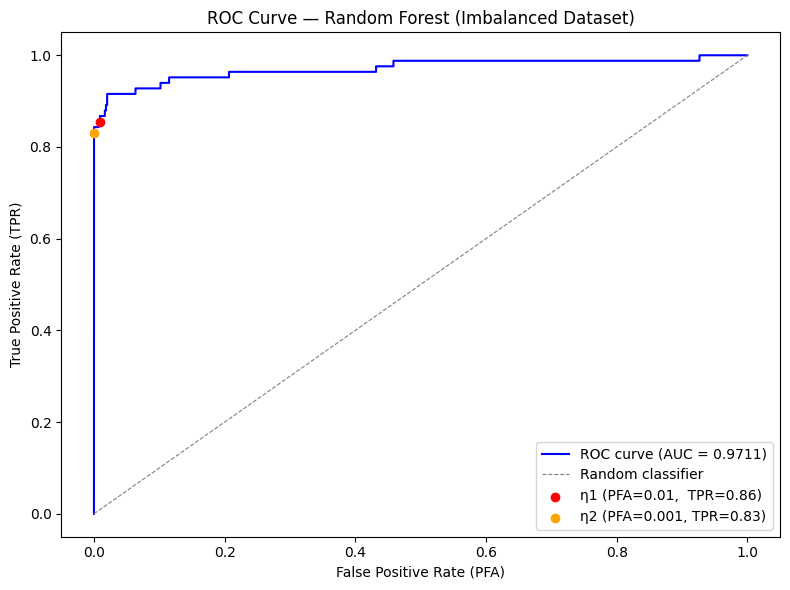


Classification report at η1 (threshold=0.0038):
              precision    recall  f1-score   support

           0       1.00      0.99      1.00     45486
           1       0.15      0.86      0.25        83

    accuracy                           0.99     45569
   macro avg       0.57      0.92      0.62     45569
weighted avg       1.00      0.99      0.99     45569


Classification report at η2 (threshold=0.3917):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45486
           1       0.91      0.83      0.87        83

    accuracy                           1.00     45569
   macro avg       0.95      0.92      0.93     45569
weighted avg       1.00      1.00      1.00     45569



In [6]:
########################
# ROC & THRESHOLDS     #
########################
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Get predicted probabilities on validation set
y_scores = best_rf.predict_proba(X_val_imb)[:, 1]

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_val_imb, y_scores)
roc_auc = auc(fpr, tpr)

# Find η1 (PFA ≈ 0.01) and η2 (PFA ≈ 0.001)
idx1 = np.argmin(np.abs(fpr - 0.01))
idx2 = np.argmin(np.abs(fpr - 0.001))

eta1 = thresholds[idx1]
eta2 = thresholds[idx2]

print(f"η1 — PFA ≈ 0.01:  threshold = {eta1:.4f} | actual PFA = {fpr[idx1]:.4f} | TPR = {tpr[idx1]:.4f}")
print(f"η2 — PFA ≈ 0.001: threshold = {eta2:.4f} | actual PFA = {fpr[idx2]:.4f} | TPR = {tpr[idx2]:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', lw=1.5, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=0.8, label='Random classifier')

# Mark thresholds
plt.scatter(fpr[idx1], tpr[idx1], color='red',    zorder=5, label=f'η1 (PFA=0.01,  TPR={tpr[idx1]:.2f})')
plt.scatter(fpr[idx2], tpr[idx2], color='orange', zorder=5, label=f'η2 (PFA=0.001, TPR={tpr[idx2]:.2f})')

plt.xlabel('False Positive Rate (PFA)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC Curve — Random Forest (Imbalanced Dataset)')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Evaluate hard decisions at each threshold
for name, eta, idx in [('η1', eta1, idx1), ('η2', eta2, idx2)]:
    y_pred_thresh = (y_scores >= eta).astype(int)
    print(f"\nClassification report at {name} (threshold={eta:.4f}):")
    print(classification_report(y_val_imb, y_pred_thresh))

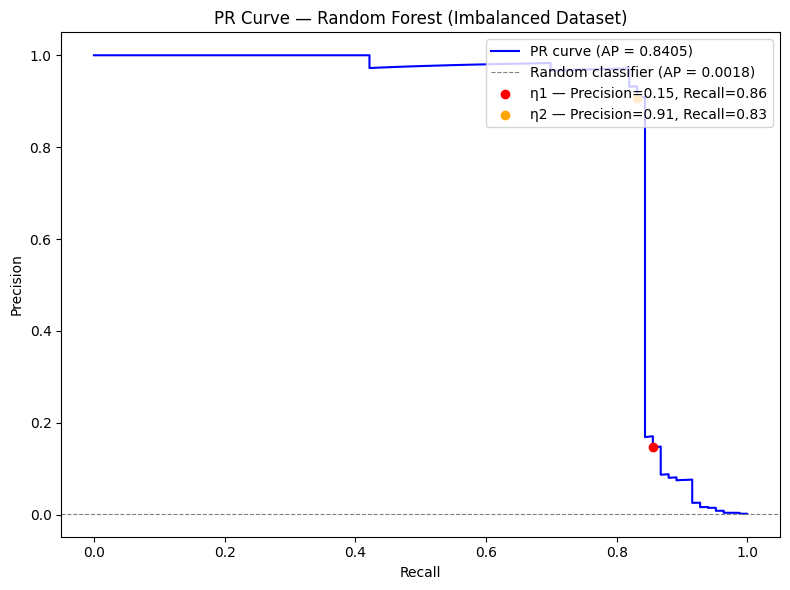

Average Precision (AP): 0.8405
Baseline AP (random):   0.0018
Improvement over random: 461.5x


In [7]:
########################
# PR CURVE             #
########################
from sklearn.metrics import precision_recall_curve, average_precision_score

precision, recall, pr_thresholds = precision_recall_curve(y_val_imb, y_scores)
ap = average_precision_score(y_val_imb, y_scores)

# Find PR points closest to η1 and η2
idx_pr1 = np.argmin(np.abs(pr_thresholds - eta1))
idx_pr2 = np.argmin(np.abs(pr_thresholds - eta2))

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='blue', lw=1.5, label=f'PR curve (AP = {ap:.4f})')
plt.axhline(y=y_val_imb.mean(), color='gray', linestyle='--', lw=0.8, label=f'Random classifier (AP = {y_val_imb.mean():.4f})')

# Mark η1 and η2
plt.scatter(recall[idx_pr1], precision[idx_pr1], color='red',    zorder=5, label=f'η1 — Precision={precision[idx_pr1]:.2f}, Recall={recall[idx_pr1]:.2f}')
plt.scatter(recall[idx_pr2], precision[idx_pr2], color='orange', zorder=5, label=f'η2 — Precision={precision[idx_pr2]:.2f}, Recall={recall[idx_pr2]:.2f}')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('PR Curve — Random Forest (Imbalanced Dataset)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()

print(f"Average Precision (AP): {ap:.4f}")
print(f"Baseline AP (random):   {y_val_imb.mean():.4f}")
print(f"Improvement over random: {ap / y_val_imb.mean():.1f}x")

Ivan's Markdown
From the ROC curves above, observe that... In contrast to... This could be due to...

# **Task C.3 - Calibration**
To calibrate the data, we consider:
- Platt Scaling
- Isotonic Regression
- Spline Calibration

In [ ]:
# Platt Scaling
from sklearn.calibration import CalibratedClassifierCV  


NameError: name 'classifier_xgb' is not defined

In [ ]:
# Isotonic Regression

In [ ]:
# Spline Calibration